IPYNB notebook to preprocess data imported from matlab, and convert it into the format accepted by the input

plotting the experimental data

In [1]:
import scipy.io
import pandas as pd
import matplotlib as plt
import numpy as np
from matplotlib import pyplot
from matplotlib import markers

HK plane (dim3)

Text(0.5, 1.0, 'HK plane L=0 ,PBCO experimental fitted peaks')

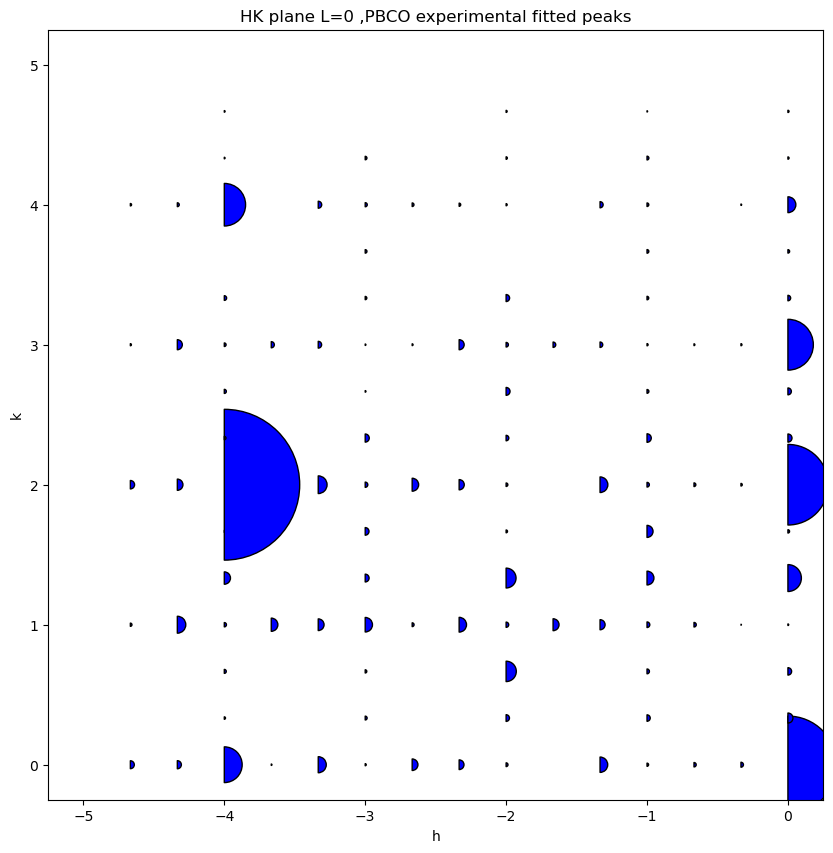

In [2]:
    # Load data
h_coords = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/dim3/h_coords.csv', header=None).values.flatten()
k_coords = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/dim3/k_coords.csv', header=None).values.flatten()
intensity_arr = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/dim3/300K_L3_intensity_arr.csv', header=None).values

h , k = np.meshgrid(h_coords , k_coords)

h_flat = h.flatten()
k_flat = k.flatten()
intensity_flat = intensity_arr.flatten()

# copy_h_flat = h_flat
# h_flat = l_flat
# l_flat = copy_h_flat


pyplot.scatter(h_flat , k_flat , s=intensity_flat *10 , color='blue', edgecolor="black",
               label='Exp', marker=markers.MarkerStyle("o", fillstyle="right"))
#change figure size
pyplot.gcf().set_size_inches(10, 10)
#add labels
pyplot.xlabel('h')
pyplot.ylabel('k')
#add title
pyplot.title('HK plane L=0 ,PBCO experimental fitted peaks')

create a csv file with 4 columns. first column is for h_coords, then for k_coords, and then for l_coords (all equal to 0). then another row for the experimental intensity, with title 'intensity_exp'.

In [3]:
#create a csv file with the data, and each first row is the name of the column : h ,k , l , intensity_exp
data = pd.DataFrame({
    'h': h_flat,
    'k': k_flat,
    'l': np.ones_like(h_flat) * 9,
    'intensity_exp': intensity_flat,
    'intensity_exp_err' : np.zeros_like(h_flat)
})

#remove all rows where the intensity_exp is nan
data = data[~data['intensity_exp'].isna()]

#remove all rows where h and k are both integers
data = data[~((data['h'] % 1 == 0) & (data['k'] % 1 == 0))]
#remove all rows where either h or k are both less than 1
data = data[~((data['h'] < 1) & (data['k'] < 1))]
data = data[data['h'] > -5]
data = data[data['k'] < 5]
# #only keep the 1/3 peaks along h
# data['h'] = np.round(data['h'] * 9)
# data['h'] = data['h'].astype(int)
# data = data[data['h'] % (3) == 0]
# data['h'] = data['h'].astype(float)
# data['h'] = data['h'] / 9


# data['k'] = np.round(data['k'] * 9)
# data['k'] = data['k'].astype(int)
# data = data[data['k'] % (3) == 0]
# data['k'] = data['k'].astype(float)
# data['k'] = data['k'] / 9


data.to_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/dim3/300K_L9_peaks.csv', index=False)
print(data)

            h         k    l  intensity_exp  intensity_exp_err
49  -0.333333  1.000000  9.0       0.813028                0.0
50  -0.666667  1.000000  9.0       0.000000                0.0
52  -1.333333  1.000000  9.0       2.398497                0.0
53  -1.666667  1.000000  9.0       2.668246                0.0
55  -2.333333  1.000000  9.0      10.797704                0.0
..        ...       ...  ...            ...                ...
234 -3.333333  4.666667  9.0       0.000000                0.0
235 -3.666667  4.666667  9.0       0.000000                0.0
236 -4.000000  4.666667  9.0       0.491956                0.0
237 -4.333333  4.666667  9.0       0.000000                0.0
238 -4.666667  4.666667  9.0       0.000000                0.0

[158 rows x 5 columns]


DIM2

# concatinate all the peaks together

In [3]:
L0 = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/dim3/300K_L0_peaks.csv')
L3 = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/dim3/300K_L3_peaks.csv')
L6 = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/dim3/300K_L6_peaks.csv')
L9 = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/dim3/300K_L9_peaks.csv')
L12 = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/dim3/300K_L12_peaks.csv')
# concatinate all the peaks together
data = pd.concat([L0, L3, L6 , L9, L12], ignore_index=True)
#remove all rows where intensity_exp is 0
data = data[data['intensity_exp'] > 0]
print(data)

print(data.shape)

data.to_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3/raw_data/1_3_combined_peaks_300K_no0.csv', index=False)


intensity_exp = data['intensity_exp'].astype(float)
intensity_exp = np.log10(intensity_exp + 1) 
data['intensity_exp'] = intensity_exp



            h    k     l  intensity_exp  intensity_exp_err
0   -0.333333  1.0   0.0       1.541749                0.0
1   -0.666667  1.0   0.0       2.780074                0.0
2   -1.333333  1.0   0.0      32.689179                0.0
4   -2.333333  1.0   0.0       7.499321                0.0
5   -2.666667  1.0   0.0      17.455100                0.0
..        ...  ...   ...            ...                ...
711 -0.666667  4.0  12.0       0.380695                0.0
712 -1.333333  4.0  12.0       0.712439                0.0
714 -2.333333  4.0  12.0       0.454016                0.0
716 -3.333333  4.0  12.0       1.477032                0.0
717 -3.666667  4.0  12.0       0.143220                0.0

[282 rows x 5 columns]
(282, 5)


m: 9.173748612729123e-26
hbar: 1.0545718176461565e-34
kb: 1.380649e-23
tD: 753.1888376153266
d_1: 0.537451510651458
exp_fact: 0.0008115092576829611


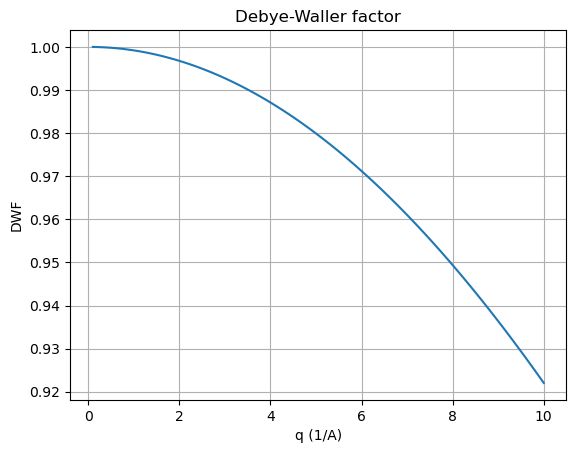

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants
import math
import xrayutilities as xu

crystal = xu.materials.Crystal.fromCIF('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/P2/PBCO_1_3_P2.cif')
m = 0.0
im = 0
for a, _, _, b in crystal.lattice.base():
    m += a.weight
    im += 1
m = m / float(im)

print(f"m: {m}")


def Debye1(x):
    """
    function to calculate the first Debye function [1]_ as needed
    for the calculation of the thermal Debye-Waller-factor
    by numerical integration

    .. math:: D_1(x) = (1/x) \int_0^x t/(\exp(t)-1) dt

    Parameters
    ----------
    x : float
        argument of the Debye function

    Returns
    -------
    float
        D1(x)  float value of the Debye function

    References
    ----------
    .. [1] http://en.wikipedia.org/wiki/Debye_function
     """

    def __int_kernel(t):
        """
        integration kernel for the numeric integration
        """
        y = t / (np.exp(t) - 1)
        return y

    if x > 0.:
        integral = scipy.integrate.quad(__int_kernel, 0, x)
        d1 = (1 / float(x)) * integral[0]
    else:
        integral = (0, 0)
        d1 = 1.

    return d1


temp = 300  # Kelvin
# W(q) = 3/2* hbar^2*q^2/(m*kB*tD) * (D1(tD/T)/(tD/T) + 1/4)
# DWF = exp(-W(q)) consistent with Vaclav H. and several books
hbar = scipy.constants.hbar
kb = scipy.constants.Boltzmann
print(f"hbar: {hbar}")
print(f"kb: {kb}")
angs = 1.0e-10
cell_length_a = 3.82030#34.38270
cell_length_b = 3.88548  # 311.68350 * 3
cell_length_c = 11.6835 # 34.96932
volume = cell_length_a * cell_length_b * cell_length_c
volume = volume * (angs ** 3)  # m^3
n_atoms = 13 # 3159
sound_v = 6000  # m/s
tD = (hbar * sound_v)/kb * ((6*n_atoms*np.pi**2)/volume) ** (1 / 3)  # Debye temperature
print(f"tD: {tD}")

d_1 = Debye1(tD / temp)
print(f"d_1: {d_1}")
x = tD / temp
exp_fact = 3 / 2. * hbar ** 2 * 1.0e20 / (m * kb * tD) * (Debye1(x) / x + 0.25)
print(f"exp_fact: {exp_fact}")
example_qs = np.linspace(0.1, 10, 100)
dwf = np.exp(-exp_fact * example_qs ** 2)
plt.plot(example_qs, dwf)
plt.xlabel('q (1/A)')
plt.ylabel('DWF')
plt.title('Debye-Waller factor')
plt.grid()
plt.savefig('debye_waller.png')


In [3]:
structure_type = 'P2'
structure_name = 'PBCO_1_3_' + structure_type

Find where to add the shifts in the list of atom coordinates. 

add the atom displacement distortions

1. check the cif file, section `_iso_parent-to-child.transform_Pp_abc` ( very end of the cif file), change the transformation accordingly in `functions`

# Print all the atom coords

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants
import math
import xrayutilities as xu

path = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/'+ structure_name + '.cif'
path_coords = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/' + structure_name + '_coords.txt'

crystal = xu.materials.Crystal.fromCIF(path)
with open(path_coords, 'w') as f:
    for a, n, c, d in crystal.lattice.base():
        #remove commas and replace (number) with 'number' for n[0]
        a = str(a).replace('(', "'").replace(')', "'")
        print(a)
        f.write(f"{a} {n[0]} {n[1]} {n[2]}\n")


# 3. replace double spacing with single spacing


Pr '59'
Pr '59'
Pr '59'
Pr '59'
Pr '59'
Pr '59'
Pr '59'
Pr '59'
Pr '59'
Ba '56'
Ba '56'
Ba '56'
Ba '56'
Ba '56'
Ba '56'
Ba '56'
Ba '56'
Ba '56'
Ba '56'
Ba '56'
Ba '56'
Ba '56'
Ba '56'
Ba '56'
Ba '56'
Ba '56'
Ba '56'
Cu '29'
Cu '29'
Cu '29'
Cu '29'
Cu '29'
Cu '29'
Cu '29'
Cu '29'
Cu '29'
Cu '29'
Cu '29'
Cu '29'
Cu '29'
Cu '29'
Cu '29'
Cu '29'
Cu '29'
Cu '29'
Cu '29'
Cu '29'
Cu '29'
Cu '29'
Cu '29'
Cu '29'
Cu '29'
Cu '29'
Cu '29'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'
O ' 8'


# The following code adds the atomic displacement variables. 

Things to do beforehand:
1. Go to `PrNiO2_C4_info.cif` , find `_atom_site_fract_symmform`
2. copy the info in `_atom_site_fract_symmform` to a new file called `PrNiO2_C4_atom_site_fract_symmform.txt`
3. In `PrNiO2_C4_atom_site_fract_symmform.txt`:
3.1 replace commas with a single space
3.2 replace double space with single space
4. change the output file name to the corresponding crystal

Output:
`PrNiO2_C4_coords_processed.txt` and `PrNiO2_C4_shift_names.txt`

1. in `PrNiO2_C4_coords_processed.txt` , remove all "
2. remove the comma in the last line
3. copy all into `functions`, and into `atom_position_list`

1. in `PrNiO2_C4_shift_names.txt` , copy to variables list in `atom_position_list`

In [18]:
path_distortions = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/' + structure_name + '_atom_site_fract_symmform.txt'

#create file if it doesn't exist
with open(path_distortions, 'w') as f:
    pass

In [34]:
#load a text file into a dataframe
path_processed_coords = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/' + structure_name + '_coords_processed.txt'
path_shift_names = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/' + structure_name + '_shift_names.txt'

PBCO_coords = pd.read_csv(path_coords ,sep="\s+", header=None)
PBCO_distortions = pd.read_csv(path_distortions , delim_whitespace=True, header=None)


#load PBCO_distortions into a list of lists
PBCO_distortions = PBCO_distortions.values.tolist()
PBCO_coords = PBCO_coords.values.tolist()

#create a new column in PBCO_distortions, which adds the second column up cumulatively
PBCO_distortions = pd.DataFrame(PBCO_distortions)
PBCO_coords = pd.DataFrame(PBCO_coords)

# print(PBCO_coords)
# print(PBCO_distortions)

PBCO_coords[2] = PBCO_coords[2].astype(str)
PBCO_coords[3] = PBCO_coords[3].astype(str)
PBCO_coords[4] = PBCO_coords[4].astype(str)


PBCO_distortions[11] = PBCO_distortions[2].cumsum()

#create a list to store all the names of shift name variables
shift_names = []

for i in range(len(PBCO_distortions)):
    #take the ith and ith + 1 element in the last column, and load them into a variable called num_atom_start and num_atom_end. if i is 1 , then num_atom_start must equal to 1, and num_atom_end must equal to the first element in the last column
    if i == 0:
        num_atom_start = 0
        num_atom_end = PBCO_distortions.iloc[i, -1]
    else:
        num_atom_start = PBCO_distortions.iloc[i, -1] - PBCO_distortions.iloc[i, 2]
        num_atom_end = PBCO_distortions.iloc[i, -1]
    
    #check if there are Dx , Dy , Dz in the 3rd , 4th and 5th columns of PBCO_distortions
    if 'Dx' in PBCO_distortions.iloc[i, 8]:
        #string the char in the first column ith row to 'Dx'
        dx_shift_name = PBCO_distortions.iloc[i, 0] + '_dx'
    else:
        dx_shift_name = 0
    if 'Dy' in PBCO_distortions.iloc[i, 9]:
        #string the char in the first column ith row to 'Dy'
        dy_shift_name = PBCO_distortions.iloc[i, 0] + '_dy'
    elif 'Dx' in PBCO_distortions.iloc[i, 9]:
        #string the char in the first column ith row to 'Dy'
        dy_shift_name = PBCO_distortions.iloc[i, 0] + '_dx'
    else:
        dy_shift_name = 0
    if 'Dz' in PBCO_distortions.iloc[i, 10]:
        #string the char in the first coumn ith row to 'Dz'
        dz_shift_name = PBCO_distortions.iloc[i, 0] + '_dz' 
    elif 'Dy' in PBCO_distortions.iloc[i, 10]:
        #string the char in the first column ith row to 'Dz'
        dz_shift_name = PBCO_distortions.iloc[i, 0] + '_dy'
    elif 'Dx' in PBCO_distortions.iloc[i, 10]:
        #string the char in the first column ith row to 'Dz'
        dz_shift_name = PBCO_distortions.iloc[i, 0] + '_dx'
    else:
        dz_shift_name = 0



    if dx_shift_name != 0:
        shift_names.append(dx_shift_name)
        for j in range(num_atom_start, num_atom_end):
            PBCO_coords.iloc[j, 2] = str(PBCO_coords.iloc[j, 2] + ' + ') + dx_shift_name
    if dy_shift_name != 0:
        shift_names.append(dy_shift_name)
        for j in range(num_atom_start, num_atom_end):
            PBCO_coords.iloc[j, 3] = str(PBCO_coords.iloc[j, 3] + ' + ') + dy_shift_name
    if dz_shift_name != 0:
        shift_names.append(dz_shift_name)
        for j in range(num_atom_start, num_atom_end):
            PBCO_coords.iloc[j, 4] = str(PBCO_coords.iloc[j, 4] + ' + ') + dz_shift_name


for k in range(len(PBCO_coords)):
    PBCO_coords.iloc[k, 0] = str("['" + PBCO_coords.iloc[k, 0] + "'")
    PBCO_coords.iloc[k, 2] = str('[' + PBCO_coords.iloc[k, 2])
    PBCO_coords.iloc[k, 4] = str(PBCO_coords.iloc[k, 4] + "]],")

print(PBCO_coords)
with open(path_processed_coords, 'w') as f:
    for i in range(len(PBCO_coords)):
        f.write(f"{PBCO_coords.iloc[i, 0]}, {PBCO_coords.iloc[i, 1]}, {PBCO_coords.iloc[i, 2]}, {PBCO_coords.iloc[i, 3]}, {PBCO_coords.iloc[i, 4]}\n")
#save PBCO_coords to a csv file
# PBCO_coords.to_csv(path_processed_coords, index=False, header=False)


print(shift_names)
# Convert shift_names to a DataFrame
shift_names = pd.DataFrame(shift_names)
#print all shift_names into a single line
shift_names_txt = shift_names[0].str.cat(sep=', ')
print(shift_names)
# Save shift_names to a text file
with open(path_shift_names, 'w') as f:
    f.write(shift_names_txt)


         0     1                               2                 3  \
0    ['Pr'  '59'             [0.83333 + Pr1_1_dx               0.5   
1    ['Pr'  '59'  [0.1666699999999999 + Pr1_1_dx               0.5   
2    ['Pr'  '59'  [0.1666699999999999 + Pr1_1_dx               0.5   
3    ['Pr'  '59'             [0.83333 + Pr1_1_dx               0.5   
4    ['Pr'  '59'             [0.83333 + Pr1_2_dx               0.5   
..     ...   ...                             ...               ...   
112   ['O'   '8'              [0.33333 + O4_4_dx  0.8416 + O4_4_dy   
113   ['O'   '8'              [0.66667 + O4_4_dx  0.8416 + O4_4_dy   
114   ['O'   '8'              [0.33333 + O4_4_dx  0.1584 + O4_4_dy   
115   ['O'   '8'              [0.33333 + O4_4_dx  0.8416 + O4_4_dy   
116   ['O'   '8'              [0.66667 + O4_4_dx  0.1584 + O4_4_dy   

                         4  
0    0.16667 + Pr1_1_dz]],  
1    0.16667 + Pr1_1_dz]],  
2    0.83333 + Pr1_1_dz]],  
3    0.83333 + Pr1_1_dz]],  
4             

C:\Users\User\AppData\Local\Temp\ipykernel_3264\1265248070.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  PBCO_distortions = pd.read_csv(path_distortions , delim_whitespace=True, header=None)


# the following code is only applicable if the parameters are the atomic displacements. to fit the modes directly, skip to the next section

Preprocess get mode amplitudes

In [ ]:
mode_names = pd.read_csv('raw_data/displacivemode_names.txt' , delim_whitespace=True, header=None)
mode_matrix = pd.read_csv('raw_data/mode_matrix.txt' , delim_whitespace=True, header=None)

#CONVERT TO A LIST OF LISTS
mode_names = mode_names.values.tolist()

# Convert mode_names to a DataFrame
mode_names = pd.DataFrame(mode_names)

num_modes = len(mode_names) 
print(num_modes)

mode_name1 = []
# rewrite the mode names into a new list with the first column as the mode name 
for i in range(num_modes):
    mode_name1.append(str('"' + str(mode_names.iloc[i, 1]) + '"' + ': '))

print(mode_name1)


445
['"[1/9,1/9,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a)": ', '"[1/9,1/9,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a)": ', '"[0,1/9,0]DT1(a,0)[Pr1:h:dsp]B2u(a)": ', '"[0,2/9,0]DT1(a,0)[Pr1:h:dsp]B2u(a)": ', '"[0,1/3,0]DT1(a,0)[Pr1:h:dsp]B2u(a)": ', '"[0,4/9,0]DT1(a,0)[Pr1:h:dsp]B2u(a)": ', '"[1/9,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a)": ', '"[2/9,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a)": ', '"[1/3,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a)": ', '"[4/9,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a)": ', '"[1/9,2/9,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a)": ', '"[1/9,2/9,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a)": ', '"[1/9,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a)": ', '"[1/9,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a)": ', '"[1/9,4/9,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a)": ', '"[1/9,4/9,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a)": ', '"[2/9,1/9,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a)": ', '"[2/9,1/9,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a)": ', '"[2/9,2/9,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a)": ', '"[2/9,2/9,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a)": ', '"[2/9,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a)": ', '"[2/9,1/3,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a)": ', '

C:\Users\User\AppData\Local\Temp\ipykernel_25560\395762485.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_names = pd.read_csv('raw_data/displacivemode_names.txt' , delim_whitespace=True, header=None)
C:\Users\User\AppData\Local\Temp\ipykernel_25560\395762485.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_matrix = pd.read_csv('raw_data/mode_matrix.txt' , delim_whitespace=True, header=None)


In [168]:
#make a zeros array with len(shift_names) rows and columns
mode_np_matrix = np.zeros((num_modes, num_modes))

print(mode_np_matrix.shape)
print(mode_np_matrix)

#load the third column values from mode_matrix into mode_np_matrix.first column of ith row is the row number of the matrix, second column is the column number of the matrix, third column is the value of the matrix
for i in range(len(mode_matrix)):
    row = mode_matrix.iloc[i, 0] - 1
    col = mode_matrix.iloc[i, 1] - 1
    value = mode_matrix.iloc[i, 2]
    mode_np_matrix[row, col] = value

print(mode_np_matrix)


print(mode_name1)


for row in range(num_modes):
    for col in range(num_modes):
        if mode_np_matrix[row, col] != 0:
            shift_name = shift_names.iloc[col,0]
            
            if mode_np_matrix[row, col] < 0:
                matrix_element = mode_np_matrix[row, col] * -1
                string_mode_np_matrix = str(matrix_element)
                dependent = ' - ' + string_mode_np_matrix + ' * ' + shift_name
            else:
                string_mode_np_matrix = str(mode_np_matrix[row, col])
                dependent = ' + ' + string_mode_np_matrix + ' * ' + shift_name
            
            mode_name1[row] = str(mode_name1[row]) + dependent
        else:
            mode_name1[row] = str(mode_name1[row])



# Save mode_names to a text file without using pandas
with open('raw_data/mode_names_processed.txt', 'w') as f:
    for name in mode_name1:
        f.write(name + ',' + '\n')


'''mode_names_txt = pd.DataFrame(mode_name1)
mode_names_txt.to_csv('raw_data/mode_names_processed.txt', index=False, header=False)

'''


(445, 445)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[-0.32635  0.       0.      ...  0.       0.       0.     ]
 [ 0.       0.32635  0.3473  ...  0.       0.       0.     ]
 [-0.17365  0.       0.      ...  0.       0.       0.     ]
 ...
 [ 0.       0.       0.      ...  0.       0.      -0.17365]
 [ 0.       0.       0.      ...  0.03015  0.       0.     ]
 [ 0.       0.       0.      ...  0.      -0.17365  0.     ]]
['"[1/9,1/9,0]V1(a,0;a,0)[Pr1:h:dsp]B3u(a)": ', '"[1/9,1/9,0]V1(a,0;a,0)[Pr1:h:dsp]B2u(a)": ', '"[0,1/9,0]DT1(a,0)[Pr1:h:dsp]B2u(a)": ', '"[0,2/9,0]DT1(a,0)[Pr1:h:dsp]B2u(a)": ', '"[0,1/3,0]DT1(a,0)[Pr1:h:dsp]B2u(a)": ', '"[0,4/9,0]DT1(a,0)[Pr1:h:dsp]B2u(a)": ', '"[1/9,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a)": ', '"[2/9,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a)": ', '"[1/3,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a)": ', '"[4/9,0,0]SM1(a,0)[Pr1:h:dsp]B3u(a)": ', '"[1/9,2/9,0]V1(a,0;a,0)[Pr1:h

"mode_names_txt = pd.DataFrame(mode_name1)\nmode_names_txt.to_csv('raw_data/mode_names_processed.txt', index=False, header=False)\n\n"

# This is the next section. fit the mode amplitudes directly
Things to do beforehand:
1. create txt file `PrNiO2_C4_mode_amp_bounds.txt`
2. from `PrNiO2_C4.str` file, at mode definitions, copy all mode names and their info
3. check which mode amp contains the strain mode. if mode a24 is a strain mode, put in `23` in `indices_to_zero`
4. run the file

the code should generate 2 files: `PrNiO2_C4_mode_names_variable` , `PrNiO2_C4_max_bound_vectors`

`PrNiO2_C4_mode_names_variable.txt`: copy this into `functions`, into `shift_atoms`.

`PrNiO2_C4_max_bound_vectors.txt`: remove the last comma, and load this file in the `gradient_descent.ipynb`




In [35]:
#create a text file to store the mode amplitude bounds
path_mode_amplitudes = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/' + structure_name + '_mode_amp_bounds.txt'
with open(path_mode_amplitudes, 'w') as f:
    pass

In [39]:
path_mode_name_var = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/' + structure_name + '_mode_names_variable.txt'
path_max_bound_vectors = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/' + structure_name + '_max_bound_vectors.txt'

mode_amp_bounds = pd.read_csv(path_mode_amplitudes , delim_whitespace=True, header=None)
print(mode_amp_bounds)
max_bound_vectors   = mode_amp_bounds.iloc[:, 6].values.tolist()

indices_to_zero = [7 , 19 , 31 , 39 , 47]
# Set the specified indices to zero
for index in indices_to_zero:
    max_bound_vectors[index] = 0.0

mode_names_variable = mode_amp_bounds.iloc[:, 1].values.tolist()

#remove '!' from all elements in mode_names
mode_names_variable = [name.replace('!', '') for name in mode_names_variable]

with open(path_mode_name_var, 'w') as f:
    for name in mode_names_variable:
        f.write(name + ',')

with open(path_max_bound_vectors, 'w') as f:
    for vector in max_bound_vectors:
        f.write(str(vector) + ',')


      0     1    2    3     4    5     6  \
0   prm   !a1  0.0  min -1.73  max  1.73   
1   prm   !a2  0.0  min -1.73  max  1.73   
2   prm   !a3  0.0  min -2.45  max  2.45   
3   prm   !a4  0.0  min -2.45  max  2.45   
4   prm   !a5  0.0  min -2.12  max  2.12   
5   prm   !a6  0.0  min -2.45  max  2.45   
6   prm   !a7  0.0  min -2.45  max  2.45   
7   prm   !a8  0.0  min -4.24  max  4.24   
8   prm   !a9  0.0  min -3.00  max  3.00   
9   prm  !a10  0.0  min -3.46  max  3.46   
10  prm  !a11  0.0  min -3.00  max  3.00   
11  prm  !a12  0.0  min -3.46  max  3.46   
12  prm  !a13  0.0  min -1.73  max  1.73   
13  prm  !a14  0.0  min -1.73  max  1.73   
14  prm  !a15  0.0  min -2.45  max  2.45   
15  prm  !a16  0.0  min -2.45  max  2.45   
16  prm  !a17  0.0  min -2.12  max  2.12   
17  prm  !a18  0.0  min -2.45  max  2.45   
18  prm  !a19  0.0  min -2.45  max  2.45   
19  prm  !a20  0.0  min -4.24  max  4.24   
20  prm  !a21  0.0  min -3.00  max  3.00   
21  prm  !a22  0.0  min -3.46  m

C:\Users\User\AppData\Local\Temp\ipykernel_3264\78257649.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_amp_bounds = pd.read_csv(path_mode_amplitudes , delim_whitespace=True, header=None)


# displacive mode names
1. create `displacive_modes.txt` file
2. from cif file, copy `_iso_displacivemode_value`

In [ ]:
path_displacive_modes = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/' + structure_name + '_displacive_modes.txt'
with open(path_displacive_modes, 'w') as f:
    pass

# construct a matrix which describes the atom shifts caused by the distortion modes

1. go to `PrNiO2_C4_info.str`
2. find `mode-amplitude to delta transformation`, copy to `delta_transform` file
3. remove `;:  0.00000` 
4. remove everything in front and including the = sign in each line
5. run code
6. remove all `'` from the file.
7. remove last comma
8. copy to `shift_atoms_copy` below
9. copy `mode_name_variable` to `shift_atoms_copy`
10. print matrix

In [37]:
path_delta_transform = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/' + structure_name + '_delta_transform.txt'
with open(path_delta_transform, 'w') as f:
    pass

In [40]:
path_delta_transform_processed = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/' + structure_name + '_delta_transform_processed.txt'

delta_transform = pd.read_csv(path_delta_transform ,header=None)
delta_transform = pd.DataFrame(delta_transform)

wanted_modes = pd.read_csv(path_mode_name_var, header=None)
wanted_modes = wanted_modes.values.flatten().tolist()
for i in range(len(wanted_modes)):
    wanted_modes[i] = str(wanted_modes[i])

# Convert delta_transform to a list of lists
delta_transform = delta_transform.values.tolist()
#string each row

with open(path_delta_transform_processed, 'w') as f:
    for row in delta_transform:
        f.write( str(row)  + ',\n')
#split each row into columns


In [41]:
def shift_atoms_copy(a1,a2,a3,a4,a5,a6,a7,a8,a9,a10,a11,a12,a13,a14,a15,a16,a17,a18,a19,a20,a21,a22,a23,a24,a25,a26,a27,a28,a29,a30,a31,a32,a33,a34,a35,a36,a37,a38,a39,a40,a41,a42,a43,a44,a45,a46,a47,a48,a49,a50,a51,a52):
    res = [
        [-  0.02519*a1 -  0.03562*a4],
        [+  0.02477*a2 +  0.03502*a3],
        [+  0.05038*a1 -  0.03562*a4],
        [-  0.04953*a2 +  0.03502*a3],
        [-  0.01781*a7 -  0.02519*a12],
        [-  0.01009*a5 +  0.02017*a8 +  0.01427*a9 +  0.01427*a11],
        [+  0.01751*a6 +  0.02477*a10],
        [+  0.03562*a7 -  0.02519*a12],
        [+  0.02017*a5 +  0.02017*a8 -  0.02853*a9 +  0.01427*a11],
        [+  0.02017*a5 +  0.02017*a8 +  0.01427*a9 -  0.02853*a11],
        [-  0.03502*a6 +  0.02477*a10],
        [-  0.04035*a5 +  0.02017*a8 -  0.02853*a9 -  0.02853*a11],
        [+  0.04953*a14 +  0.03502*a15],
        [+  0.05038*a13 +  0.03562*a16],
        [-  0.02519*a13 +  0.03562*a16],
        [-  0.02477*a14 +  0.03502*a15],
        [+  0.04035*a17 +  0.02017*a20 +  0.02853*a21 +  0.02853*a23],
        [-  0.02017*a17 +  0.02017*a20 -  0.01427*a21 +  0.02853*a23],
        [+  0.03502*a18 +  0.02477*a22],
        [+  0.03562*a19 +  0.02519*a24],
        [-  0.02017*a17 +  0.02017*a20 +  0.02853*a21 -  0.01427*a23],
        [-  0.01781*a19 +  0.02519*a24],
        [+  0.01009*a17 +  0.02017*a20 -  0.01427*a21 -  0.01427*a23],
        [-  0.01751*a18 +  0.02477*a22],
        [+  0.04953*a26 +  0.03502*a27],
        [+  0.02519*a25 +  0.03562*a28],
        [-  0.02477*a26 +  0.03502*a27],
        [-  0.05038*a25 +  0.03562*a28],
        [-  0.03562*a31 -  0.02519*a36],
        [+  0.02017*a29 +  0.02017*a32 +  0.02853*a33 +  0.01427*a35],
        [+  0.01781*a31 -  0.02519*a36],
        [-  0.01009*a29 +  0.02017*a32 -  0.01427*a33 +  0.01427*a35],
        [+  0.01751*a30 +  0.02477*a34],
        [-  0.04035*a29 +  0.02017*a32 +  0.02853*a33 -  0.02853*a35],
        [+  0.02017*a29 +  0.02017*a32 -  0.01427*a33 -  0.02853*a35],
        [-  0.03502*a30 +  0.02477*a34],
        [+  0.02017*a37 +  0.02017*a40 +  0.01427*a41 +  0.02853*a43],
        [+  0.03502*a38 +  0.02477*a42],
        [-  0.04035*a37 +  0.02017*a40 -  0.02853*a41 +  0.02853*a43],
        [+  0.01781*a39 +  0.02519*a44],
        [-  0.01009*a37 +  0.02017*a40 +  0.01427*a41 -  0.01427*a43],
        [-  0.01751*a38 +  0.02477*a42],
        [-  0.03562*a39 +  0.02519*a44],
        [+  0.02017*a37 +  0.02017*a40 -  0.02853*a41 -  0.01427*a43],
        [+  0.04035*a45 +  0.02017*a48 +  0.02853*a49 +  0.02853*a51],
        [-  0.02017*a45 +  0.02017*a48 -  0.01427*a49 +  0.02853*a51],
        [+  0.03502*a46 +  0.02477*a50],
        [+  0.03562*a47 +  0.02519*a52],
        [-  0.02017*a45 +  0.02017*a48 +  0.02853*a49 -  0.01427*a51],
        [-  0.01781*a47 +  0.02519*a52],
        [+  0.01009*a45 +  0.02017*a48 -  0.01427*a49 -  0.01427*a51],
        [-  0.01751*a46 +  0.02477*a50]

    ]

    return res

In [42]:
num_modes = 52
matrix  = np.zeros([num_modes , num_modes])
print(np.shape(matrix))
for i in range (num_modes):
    a = np.zeros(num_modes)
    a[i] = 1
    res = np.array(shift_atoms_copy(*a))
    matrix[:,i] = res[:,0]
    #matrix[:,i] = shift_atoms(*a)

#save as txt using pandas
save_path = structure_type + '_matrix.txt'
pd.DataFrame(matrix).to_csv(save_path, header=None, index=None, sep=' ')

(52, 52)


# This is for eliminating modes after generating histograms

In [4]:
mode_amp_bounds = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/new_PBCO_fit/new_PBCO_mode_amp_bounds.txt' , delim_whitespace=True, header=None)

max_bound_vectors   = mode_amp_bounds.iloc[:, 6].values.tolist()
print(max_bound_vectors)
indices_to_zero = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/results/20250812_231021_iters7000_epochs75_lr0.1/remove_idx_list.txt', delim_whitespace=False, header=None , sep=',').values.flatten().tolist()
strain_modes = [111, 411, 711, 906, 1101]
indices_to_zero = [int(i) for i in indices_to_zero]
#concatinate strain_modes and indices_to_zero
combined_indices = strain_modes + indices_to_zero


# Set the specified indices to zero
for index in combined_indices:
    max_bound_vectors[index] = 0.0

print('max_bound_vectors:', max_bound_vectors)
with open('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/new_PBCO_fit/new_PBCO_mode_amp_bounds_ver3.txt', 'w') as f:
    for value in max_bound_vectors:
        f.write(f"{value},")

#find the number of non-zero elements
non_zero_count = np.count_nonzero(max_bound_vectors)
print('Number of non-zero elements:', non_zero_count)

[5.6, 6.36, 5.6, 11.19, 11.19, 12.73, 11.19, 12.73, 11.19, 11.19, 12.73, 11.19, 9.0, 7.91, 9.0, 7.91, 9.0, 9.0, 9.0, 7.91, 7.91, 9.0, 7.91, 9.0, 9.0, 9.0, 7.91, 9.0, 7.91, 7.91, 7.91, 7.91, 7.91, 9.0, 7.91, 7.91, 7.91, 7.91, 7.91, 7.91, 7.91, 9.0, 7.91, 7.91, 9.0, 7.91, 9.0, 7.91, 9.0, 9.0, 9.0, 7.91, 7.91, 7.91, 7.91, 7.91, 7.91, 9.0, 7.91, 7.91, 5.6, 6.36, 5.6, 5.6, 6.36, 6.36, 5.6, 6.36, 5.6, 5.6, 6.36, 5.6, 5.6, 6.36, 5.6, 5.6, 6.36, 6.36, 5.6, 6.36, 5.6, 6.36, 6.36, 5.6, 6.36, 6.36, 5.6, 6.36, 6.36, 6.36, 6.36, 6.36, 5.6, 5.6, 6.36, 5.6, 5.6, 6.36, 5.6, 5.6, 6.36, 6.36, 5.6, 6.36, 5.6, 8.29, 7.91, 8.04, 8.42, 8.04, 8.42, 22.05, 15.59, 15.83, 15.59, 15.83, 15.59, 18.0, 15.59, 15.83, 15.59, 18.0, 15.59, 15.83, 15.59, 15.83, 15.59, 18.0, 15.59, 15.83, 11.73, 11.19, 11.37, 11.91, 11.73, 11.19, 11.37, 11.91, 11.02, 12.73, 14.7, 12.73, 11.73, 11.19, 11.37, 11.91, 11.73, 11.19, 11.37, 11.91, 11.73, 11.19, 11.37, 11.91, 11.02, 12.73, 14.7, 12.73, 11.73, 11.19, 11.37, 11.91, 11.02, 11.19, 

C:\Users\User\AppData\Local\Temp\ipykernel_23040\4062915562.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mode_amp_bounds = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/new_PBCO_fit/new_PBCO_mode_amp_bounds.txt' , delim_whitespace=True, header=None)
C:\Users\User\AppData\Local\Temp\ipykernel_23040\4062915562.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  indices_to_zero = pd.read_csv('C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/results/20250812_231021_iters7000_epochs75_lr0.1/remove_idx_list.txt', delim_whitespace=False, header=None , sep=',').values.flatten().tolist()


In [5]:
matlab_displacive_modes_path = 'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/' + structure_type + '/matlab_displacive_modes.txt'


matlab_displacive_modes = pd.read_csv(matlab_displacive_modes_path , delim_whitespace=True, header=None)

#save as mat file
scipy.io.savemat(f'C:/Users/User/Desktop/uzh_intern/alrisDistortionFit/PBCO/PBCO_1_3_inplane/{structure_type}/matlab_displacive_modes.mat', {'displacive_modes': matlab_displacive_modes.values})

C:\Users\User\AppData\Local\Temp\ipykernel_15160\1753428809.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  matlab_displacive_modes = pd.read_csv(matlab_displacive_modes_path , delim_whitespace=True, header=None)
